In [3]:
!pip install pandas numpy matplotlib pillow

zsh:1: command not found: pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Matplotlib is building the font cache; this may take a moment.


In [15]:
import os

print("Working folder:", os.getcwd())
print("Metadata exists:", os.path.exists("../data/milk10k/metadata.csv"))

Working folder: /Users/claralacroix/Downloads/milk10k-skin-lesion-classification-main/notebooks
Metadata exists: False


In [16]:
metadata = pd.read_csv("../data/milk10k/metadata.csv")
training_gt = pd.read_csv("../data/milk10k/supplements/training_gt.csv")

print("Metadata shape:", metadata.shape)
print("Training GT shape:", training_gt.shape)

Metadata shape: (10480, 17)
Training GT shape: (5240, 12)


In [6]:
import os

print(os.listdir("/content"))

['.config', 'milk10k.zip', 'sample_data']


In [3]:
import zipfile

zip_path = "../data/milk10k.zip"
extract_path = "../data/milk10k"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Décompression terminée !")

Décompression terminée !


In [9]:
import os

for root, dirs, files in os.walk("../data/milk10k"):
    print(root)
    print(files[:10])

../data/milk10k
['attribution.txt', 'metadata.csv']
../data/milk10k/supplements
['training_gt.csv', 'training_input.csv', 'training_supp.csv']
../data/milk10k/licenses
['CC-BY-NC.txt']
../data/milk10k/images
['ISIC_5763649.jpg', 'ISIC_2445691.jpg', 'ISIC_5409428.jpg', 'ISIC_7725065.jpg', 'ISIC_0332749.jpg', 'ISIC_0958356.jpg', 'ISIC_4491028.jpg', 'ISIC_6728668.jpg', 'ISIC_9578110.jpg', 'ISIC_8989885.jpg']


In [12]:
import pandas as pd

metadata = pd.read_csv("../data/milk10k/metadata.csv")
training_gt = pd.read_csv("../data/milk10k/supplements/training_gt.csv")

print("Metadata :", metadata.shape)
print("Training GT :", training_gt.shape)

Metadata : (10480, 17)
Training GT : (5240, 12)


In [11]:
print("Colonnes metadata :")
print(metadata.columns.tolist())

print("\nColonnes training_gt :")
print(training_gt.columns.tolist())

Colonnes metadata :
['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_confirm_type', 'image_manipulation', 'image_type', 'lesion_id', 'melanocytic', 'sex']

Colonnes training_gt :
['lesion_id', 'AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']


In [13]:
metadata.head()

,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,concomitant_biopsy,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_4,diagnosis_confirm_type,image_manipulation,image_type,lesion_id,melanocytic,sex
0,ISIC_0051817,MILK study team,CC-BY-NC,70.0,upper extremity,NaN,True,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,histopathology,instrument only,dermoscopic,IL_1612768,NaN,male
1,ISIC_0073863,MILK study team,CC-BY-NC,5.0,NaN,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Reed",histopathology,instrument only,dermoscopic,IL_2547802,True,female
2,ISIC_0075884,MILK study team,CC-BY-NC,10.0,upper extremity,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Acral",histopathology,instrument only,clinical: close-up,IL_9270970,True,female
3,ISIC_0076255,MILK study team,CC-BY-NC,50.0,head/neck,NaN,True,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,NaN,histopathology,instrument only,dermoscopic,IL_8089688,NaN,female
4,ISIC_0077054,MILK study team,CC-BY-NC,75.0,head/neck,NaN,True,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,NaN,histopathology,instrument only,dermoscopic,IL_5271098,NaN,male


In [12]:
training_gt.head()

,lesion_id,AKIEC,BCC,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC
0,IL_0000652,0,1,0,0,0,0,0,0,0,0,0
1,IL_0003176,0,1,0,0,0,0,0,0,0,0,0
2,IL_0004688,0,1,0,0,0,0,0,0,0,0,0
3,IL_0005081,0,0,0,0,0,0,0,0,0,1,0
4,IL_0006177,0,1,0,0,0,0,0,0,0,0,0


Taille : (600, 450)
Mode : RGB


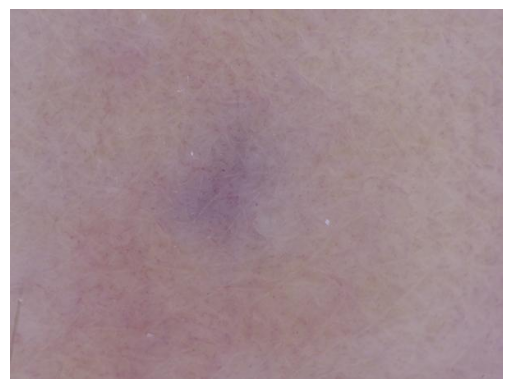

In [14]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_path = "../data/milk10k/images/ISIC_1627498.jpg"

img = Image.open(image_path)

print("Taille :", img.size)
print("Mode :", img.mode)

plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
import numpy as np

img_array = np.array(img)

print("Type :", type(img_array))
print("Shape :", img_array.shape)
print("Valeur minimale :", img_array.min())
print("Valeur maximale :", img_array.max())

Type : <class 'numpy.ndarray'>
Shape : (450, 600, 3)
Valeur minimale : 82
Valeur maximale : 197


In [16]:
class_counts = training_gt.drop(columns="lesion_id").sum().sort_values(ascending=False)

print(class_counts)

BCC        2522
NV          746
BKL         544
SCCKA       473
MEL         450
AKIEC       303
DF           52
INF          50
VASC         47
BEN_OTH      44
MAL_OTH       9
dtype: int64


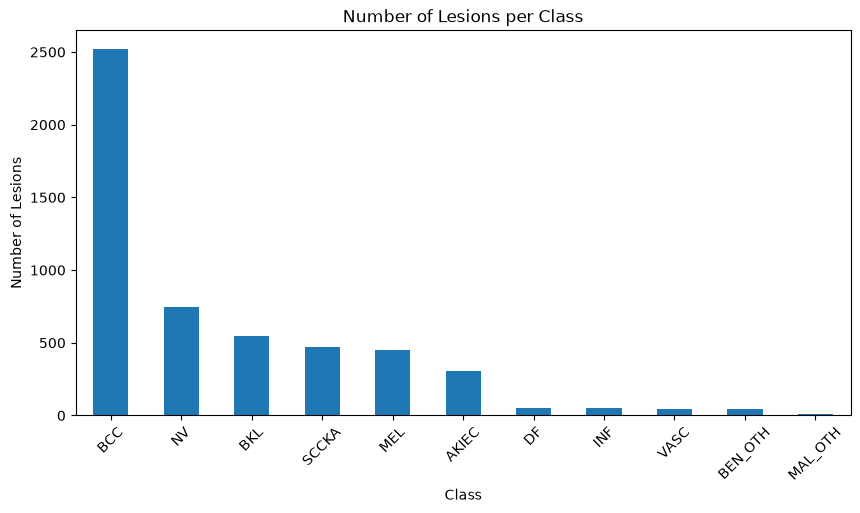

In [17]:
class_counts.plot(kind="bar", figsize=(10, 5))

plt.title("Number of Lesions per Class")
plt.xlabel("Class")
plt.ylabel("Number of Lesions")
plt.xticks(rotation=45)

plt.show()

In [18]:
# Count the number of images for each lesion
images_per_lesion = metadata.groupby("lesion_id").size()

print(images_per_lesion.value_counts())

2    5240
Name: count, dtype: int64


In [19]:
# Check whether every lesion has exactly two images
print("Number of lesions with exactly 2 images:",
      (images_per_lesion == 2).sum())

print("Total number of lesions:",
      len(images_per_lesion))

Number of lesions with exactly 2 images: 5240
Total number of lesions: 5240


In [23]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = Path("/content/milk10k")
IMG_DIR = Path("../data/milk10k/images")

def show_samples(df, img_dir, n=6, diagnosis=None, seed=0):
    subset = df if diagnosis is None else df[df["diagnosis_1"] == diagnosis]
    sample = subset.sample(n=n, random_state=seed)

    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3))

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(img_dir / f'{row["isic_id"]}.jpg').convert("RGB")
        ax.imshow(img)
        ax.set_title(row["diagnosis_1"], fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

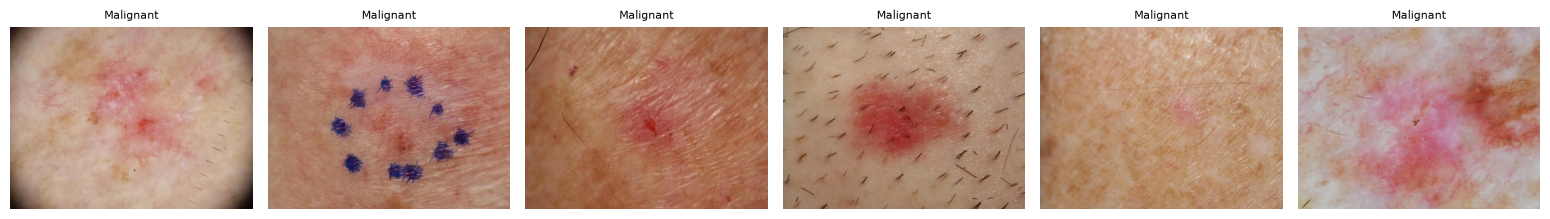

In [24]:
show_samples(metadata, IMG_DIR, n=6, diagnosis="Malignant")

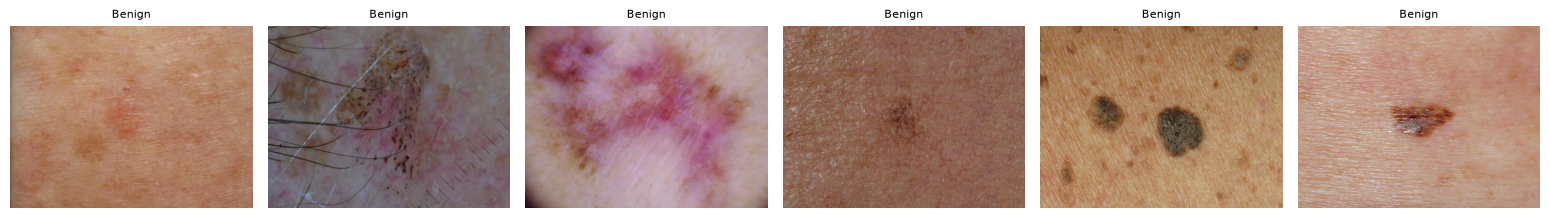

In [25]:
show_samples(metadata, IMG_DIR, n=6, diagnosis="Benign")

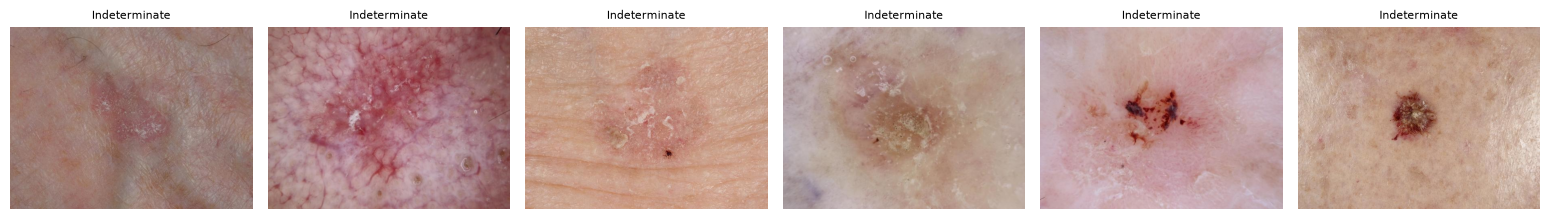

In [26]:
show_samples(metadata, IMG_DIR, n=6, diagnosis="Indeterminate")

In [27]:
malignant_counts = (
    metadata[metadata["diagnosis_1"] == "Malignant"]["diagnosis_2"]
    .value_counts()
)

print(malignant_counts)
print("\nMost common malignant diagnosis_2:")
print(malignant_counts.idxmax())

diagnosis_2
Malignant adnexal epithelial proliferations - Follicular    5044
Malignant epidermal proliferations                          1306
Malignant melanocytic proliferations (Melanoma)              900
Collision - At least one malignant proliferation              18
Name: count, dtype: int64

Most common malignant diagnosis_2:
Malignant adnexal epithelial proliferations - Follicular


In [28]:
import numpy as np
from PIL import Image

sample = metadata.sample(n=200, random_state=0)

widths = []
heights = []

for _, row in sample.iterrows():
    image_path = IMG_DIR / f'{row["isic_id"]}.jpg'
    width, height = Image.open(image_path).size

    widths.append(width)
    heights.append(height)

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Average width: 600.0
Average height: 450.0


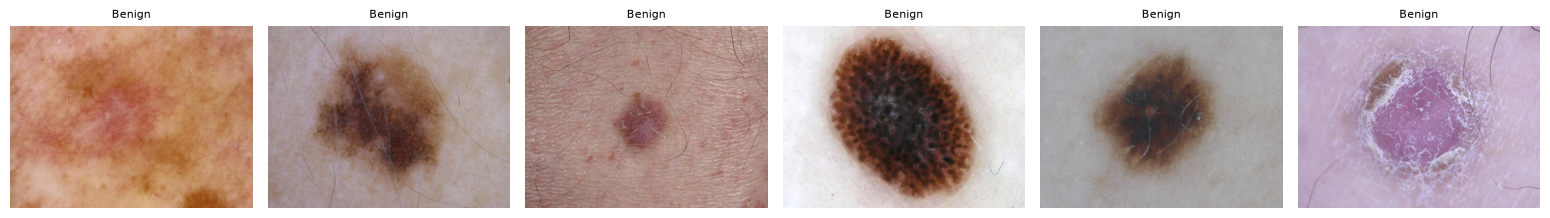

In [29]:
show_samples(metadata, IMG_DIR, n=6, diagnosis="Benign", seed=1)

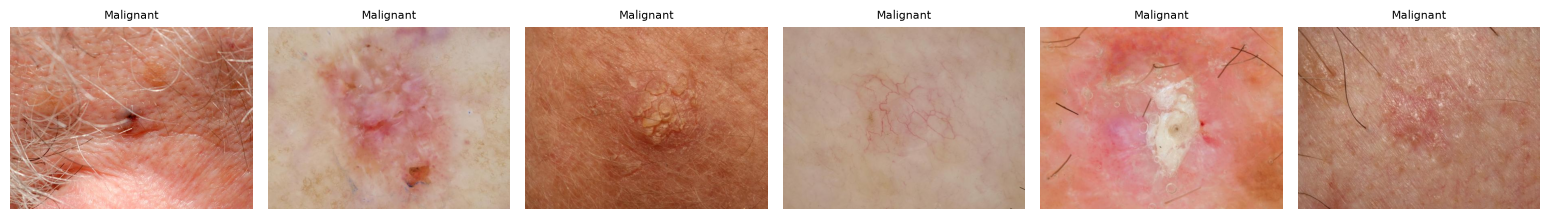

In [30]:
show_samples(metadata, IMG_DIR, n=6, diagnosis="Malignant", seed=1)

In [31]:
lesion_id = metadata["lesion_id"].iloc[0]

lesion_images = metadata[metadata["lesion_id"] == lesion_id]

print("Lesion ID:", lesion_id)
print(lesion_images[["isic_id", "lesion_id", "image_type"]])

Lesion ID: IL_1612768
          isic_id   lesion_id          image_type
0    ISIC_0051817  IL_1612768         dermoscopic
527  ISIC_0586691  IL_1612768  clinical: close-up


In [32]:
print("Diagnosis distribution:")
print(metadata["diagnosis_1"].value_counts())

print("\nMissing values:")
print(
    metadata[["age_approx", "sex", "anatom_site_general"]]
    .isna()
    .mean()
)

Diagnosis distribution:
diagnosis_1
Malignant        7268
Benign           2966
Indeterminate     246
Name: count, dtype: int64

Missing values:
age_approx             0.003817
sex                    0.000000
anatom_site_general    0.373282
dtype: float64


In [33]:
metadata[["age_approx", "sex", "anatom_site_general", "diagnosis_1"]].describe(
    include="all"
)

,age_approx,sex,anatom_site_general,diagnosis_1
count,10440.000000,10480,6568,10480
unique,NaN,2,4,3
top,NaN,male,head/neck,Malignant
freq,NaN,6304,2982,7268
mean,61.355364,NaN,NaN,NaN
std,15.691646,NaN,NaN,NaN
min,5.000000,NaN,NaN,NaN
25%,50.000000,NaN,NaN,NaN
50%,65.000000,NaN,NaN,NaN
75%,75.000000,NaN,NaN,NaN


In [34]:
# Check the number of unique lesions and images

print("Number of unique lesions:", metadata["lesion_id"].nunique())
print("Number of unique images:", metadata["isic_id"].nunique())

print("\nImages per lesion:")
print(metadata.groupby("lesion_id").size().value_counts())

Number of unique lesions: 5240
Number of unique images: 10480

Images per lesion:
2    5240
Name: count, dtype: int64


In [35]:
# Check that every lesion has exactly two images

print(
    "Every lesion has exactly two images:",
    (metadata.groupby("lesion_id").size() == 2).all()
)

Every lesion has exactly two images: True


In [1]:
print("Python is working!")

Python is working!


In [17]:
# Part 1 — Metadata Analysis

print("Metadata columns:")
print(metadata.columns.tolist())

print("\nData types:")
print(metadata.dtypes)

print("\nMissing values:")
print(metadata.isna().sum())

Metadata columns:
['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_confirm_type', 'image_manipulation', 'image_type', 'lesion_id', 'melanocytic', 'sex']

Data types:
isic_id                       str
attribution                   str
copyright_license             str
age_approx                float64
anatom_site_general           str
anatom_site_special           str
concomitant_biopsy           bool
diagnosis_1                   str
diagnosis_2                   str
diagnosis_3                   str
diagnosis_4                   str
diagnosis_confirm_type        str
image_manipulation            str
image_type                    str
lesion_id                     str
melanocytic                object
sex                           str
dtype: object

Missing values:
isic_id                       0
attribution                   0
copyright

In [18]:
# Metadata summary

metadata_summary = pd.DataFrame({
    "column": metadata.columns,
    "type": metadata.dtypes.astype(str).values,
    "missing_count": metadata.isna().sum().values,
    "missing_percent": (metadata.isna().mean() * 100).round(2).values,
    "unique_values": metadata.nunique(dropna=True).values
})

metadata_summary

,column,type,missing_count,missing_percent,unique_values
0,isic_id,str,0,0.00,10480
1,attribution,str,0,0.00,1
2,copyright_license,str,0,0.00,1
3,age_approx,float64,40,0.38,17
4,anatom_site_general,str,3912,37.33,4
5,anatom_site_special,str,10274,98.03,2
6,concomitant_biopsy,bool,0,0.00,2
7,diagnosis_1,str,0,0.00,3
8,diagnosis_2,str,0,0.00,19
9,diagnosis_3,str,158,1.51,27


In [19]:
# Part 1.2 — Target distribution by categorical metadata

categorical_cols = [
    "sex",
    "anatom_site_general",
    "anatom_site_special",
    "concomitant_biopsy",
    "diagnosis_confirm_type",
    "image_manipulation",
    "image_type",
    "melanocytic"
]

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(pd.crosstab(
        metadata[col],
        metadata["diagnosis_1"],
        normalize="index"
    ).round(3))


===== sex =====
diagnosis_1  Benign  Indeterminate  Malignant
sex                                          
female        0.332          0.017      0.651
male          0.250          0.028      0.722

===== anatom_site_general =====
diagnosis_1          Benign  Indeterminate  Malignant
anatom_site_general                                  
head/neck             0.212          0.066      0.722
lower extremity       0.317          0.007      0.676
oral/genital          0.750          0.000      0.250
upper extremity       0.210          0.014      0.777

===== anatom_site_special =====
diagnosis_1          Benign  Indeterminate  Malignant
anatom_site_special                                  
acral NOS             0.063          0.084      0.853
oral or genital       0.750          0.000      0.250

===== concomitant_biopsy =====
diagnosis_1         Benign  Indeterminate  Malignant
concomitant_biopsy                                  
False                0.871          0.107      0.022
Tr

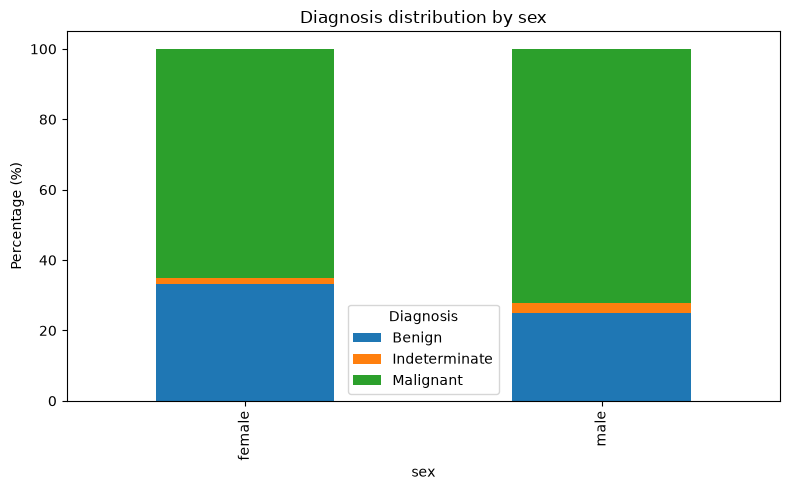

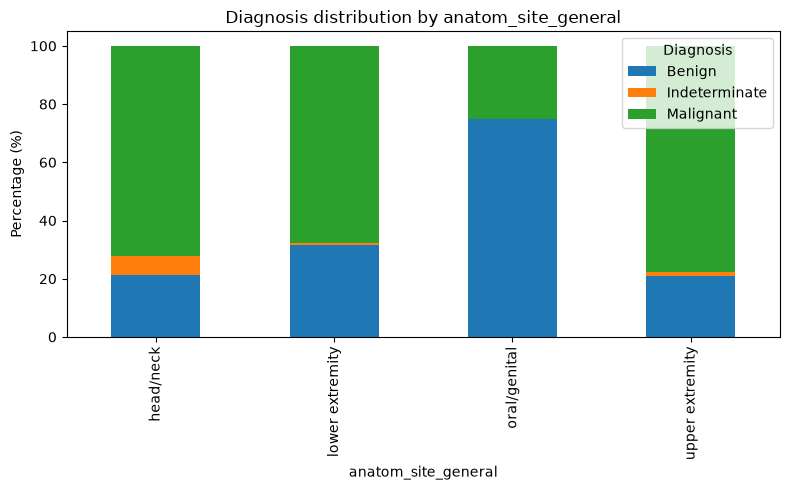

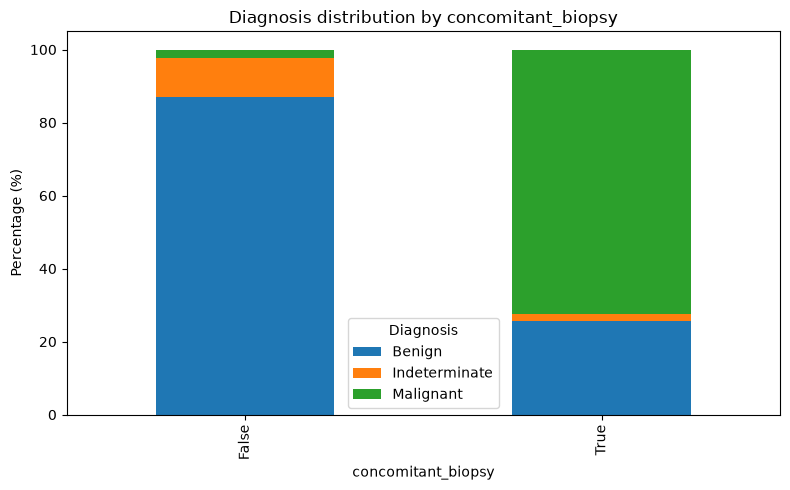

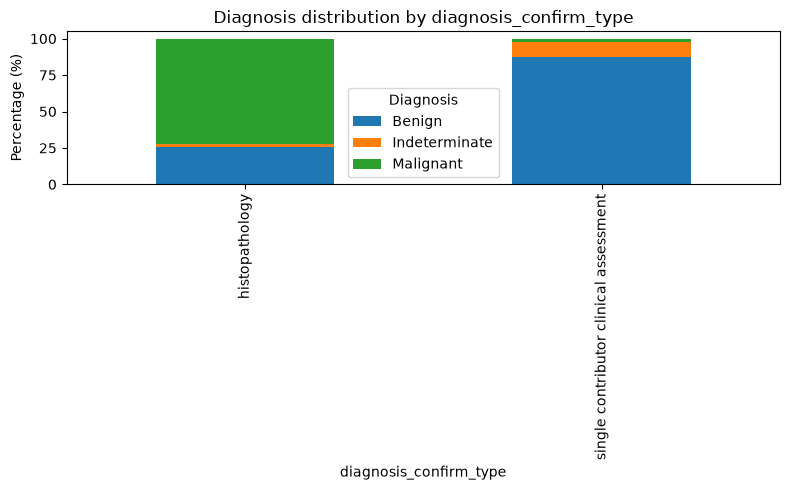

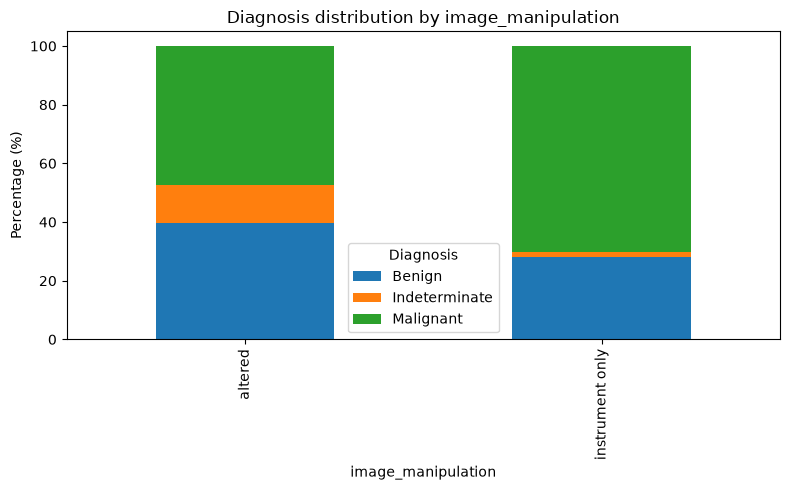

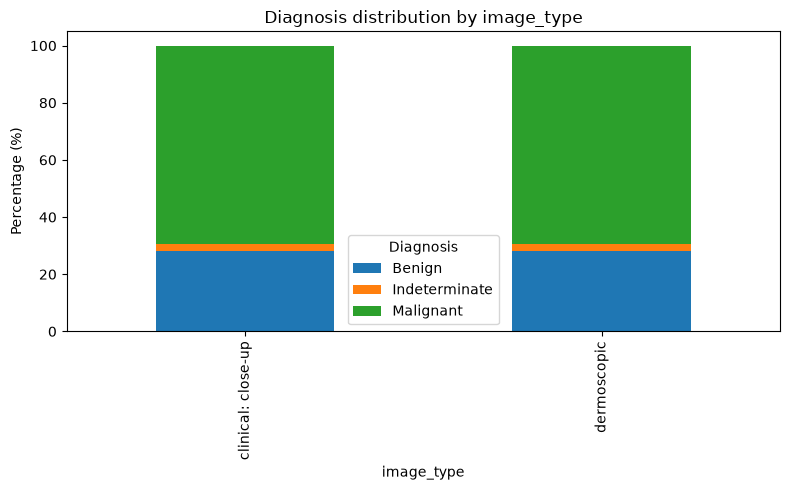

In [20]:
# Part 1.2 — Target distribution by categorical metadata
# Stacked bar charts

import matplotlib.pyplot as plt

plot_cols = [
    "sex",
    "anatom_site_general",
    "concomitant_biopsy",
    "diagnosis_confirm_type",
    "image_manipulation",
    "image_type"
]

for col in plot_cols:
    table = pd.crosstab(
        metadata[col],
        metadata["diagnosis_1"],
        normalize="index"
    ) * 100

    table.plot(kind="bar", stacked=True, figsize=(8, 5))
    plt.title(f"Diagnosis distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Percentage (%)")
    plt.legend(title="Diagnosis")
    plt.tight_layout()
    plt.show()

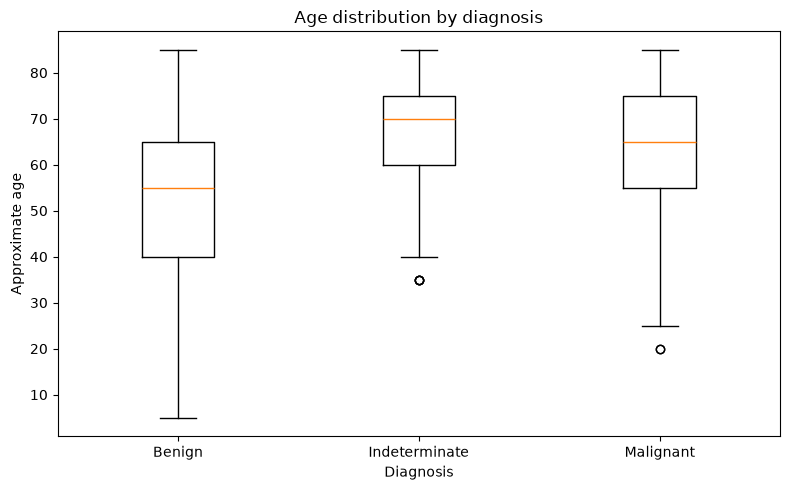

In [23]:
# Part 1.3 — Age distribution by diagnosis

plt.figure(figsize=(8, 5))

data_to_plot = [
    metadata.loc[metadata["diagnosis_1"] == "Benign", "age_approx"].dropna(),
    metadata.loc[metadata["diagnosis_1"] == "Indeterminate", "age_approx"].dropna(),
    metadata.loc[metadata["diagnosis_1"] == "Malignant", "age_approx"].dropna()
]

plt.boxplot(
    data_to_plot,
    tick_labels=["Benign", "Indeterminate", "Malignant"]
)

plt.title("Age distribution by diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Approximate age")
plt.tight_layout()
plt.show()

In [25]:
# One-way ANOVA: age vs diagnosis

from scipy.stats import f_oneway

groups = [
    group["age_approx"].dropna()
    for _, group in metadata.groupby("diagnosis_1")
]

f_stat, p_value = f_oneway(*groups)

print("ANOVA F-statistic:", f_stat)
print("p-value:", p_value)

ANOVA F-statistic: 934.9951544001453
p-value: 0.0


In [26]:
# Part 1.4 — Chi-square tests for categorical metadata

from scipy.stats import chi2_contingency

categorical_cols = [
    "sex",
    "anatom_site_general",
    "anatom_site_special",
    "concomitant_biopsy",
    "diagnosis_confirm_type",
    "image_manipulation",
    "image_type",
    "melanocytic"
]

for col in categorical_cols:
    table = pd.crosstab(metadata[col], metadata["diagnosis_1"])
    
    chi2, p, dof, expected = chi2_contingency(table)
    
    print(f"{col}: chi2 = {chi2:.2f}, p < 0.001" if p < 0.001 
          else f"{col}: chi2 = {chi2:.2f}, p = {p:.4f}")

sex: chi2 = 91.29, p < 0.001
anatom_site_general: chi2 = 249.41, p < 0.001
anatom_site_special: chi2 = 67.75, p < 0.001
concomitant_biopsy: chi2 = 1014.39, p < 0.001
diagnosis_confirm_type: chi2 = 1014.39, p < 0.001
image_manipulation: chi2 = 201.98, p < 0.001
image_type: chi2 = 0.00, p = 1.0000
melanocytic: chi2 = 0.00, p = 1.0000


In [27]:
# Part 1.5 — Strength of categorical associations (Cramér's V)

import numpy as np

def cramers_v(table):
    chi2, _, _, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape
    
    return np.sqrt(
        (chi2 / n) / min(k - 1, r - 1)
    )

for col in categorical_cols:
    table = pd.crosstab(metadata[col], metadata["diagnosis_1"])
    v = cramers_v(table)
    print(f"{col}: Cramér's V = {v:.3f}")

sex: Cramér's V = 0.093
anatom_site_general: Cramér's V = 0.138
anatom_site_special: Cramér's V = 0.573
concomitant_biopsy: Cramér's V = 0.311
diagnosis_confirm_type: Cramér's V = 0.311
image_manipulation: Cramér's V = 0.139
image_type: Cramér's V = 0.000
melanocytic: Cramér's V = nan


/var/folders/bz/0wk_t6652h57j6h5mxx5tftc0000gn/T/ipykernel_54849/292588714.py:11: RuntimeWarning: invalid value encountered in scalar divide
  (chi2 / n) / min(k - 1, r - 1)


In [29]:
# Part 2.1 — Sample images per diagnosis class

import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_dir = "../data/milk10k/images"
samples_per_class = 20

sampled_metadata = pd.concat([
    metadata[metadata["diagnosis_1"] == diagnosis].sample(
        n=20,
        random_state=42
    )
    for diagnosis in ["Benign", "Indeterminate", "Malignant"]
])

print("Images sampled per class:")
print(sampled_metadata["diagnosis_1"].value_counts())

Images sampled per class:
diagnosis_1
Benign           20
Indeterminate    20
Malignant        20
Name: count, dtype: int64


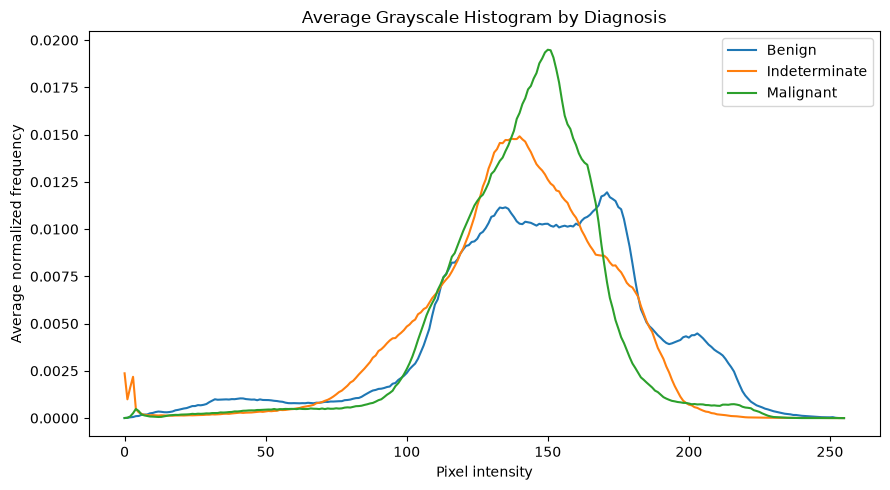

In [30]:
# Part 2.2 — Average grayscale histogram per diagnosis class

def get_grayscale_histogram(image_path):
    image = Image.open(image_path).convert("L")
    image_array = np.array(image)

    hist, _ = np.histogram(
        image_array,
        bins=256,
        range=(0, 256),
        density=True
    )

    return hist


class_histograms = {}

for diagnosis in ["Benign", "Indeterminate", "Malignant"]:
    histograms = []

    class_data = sampled_metadata[
        sampled_metadata["diagnosis_1"] == diagnosis
    ]

    for _, row in class_data.iterrows():
        image_path = os.path.join(image_dir, row["isic_id"] + ".jpg")

        if os.path.exists(image_path):
            histograms.append(get_grayscale_histogram(image_path))

    class_histograms[diagnosis] = np.mean(histograms, axis=0)


plt.figure(figsize=(9, 5))

for diagnosis, histogram in class_histograms.items():
    plt.plot(histogram, label=diagnosis)

plt.title("Average Grayscale Histogram by Diagnosis")
plt.xlabel("Pixel intensity")
plt.ylabel("Average normalized frequency")
plt.legend()
plt.tight_layout()
plt.show()

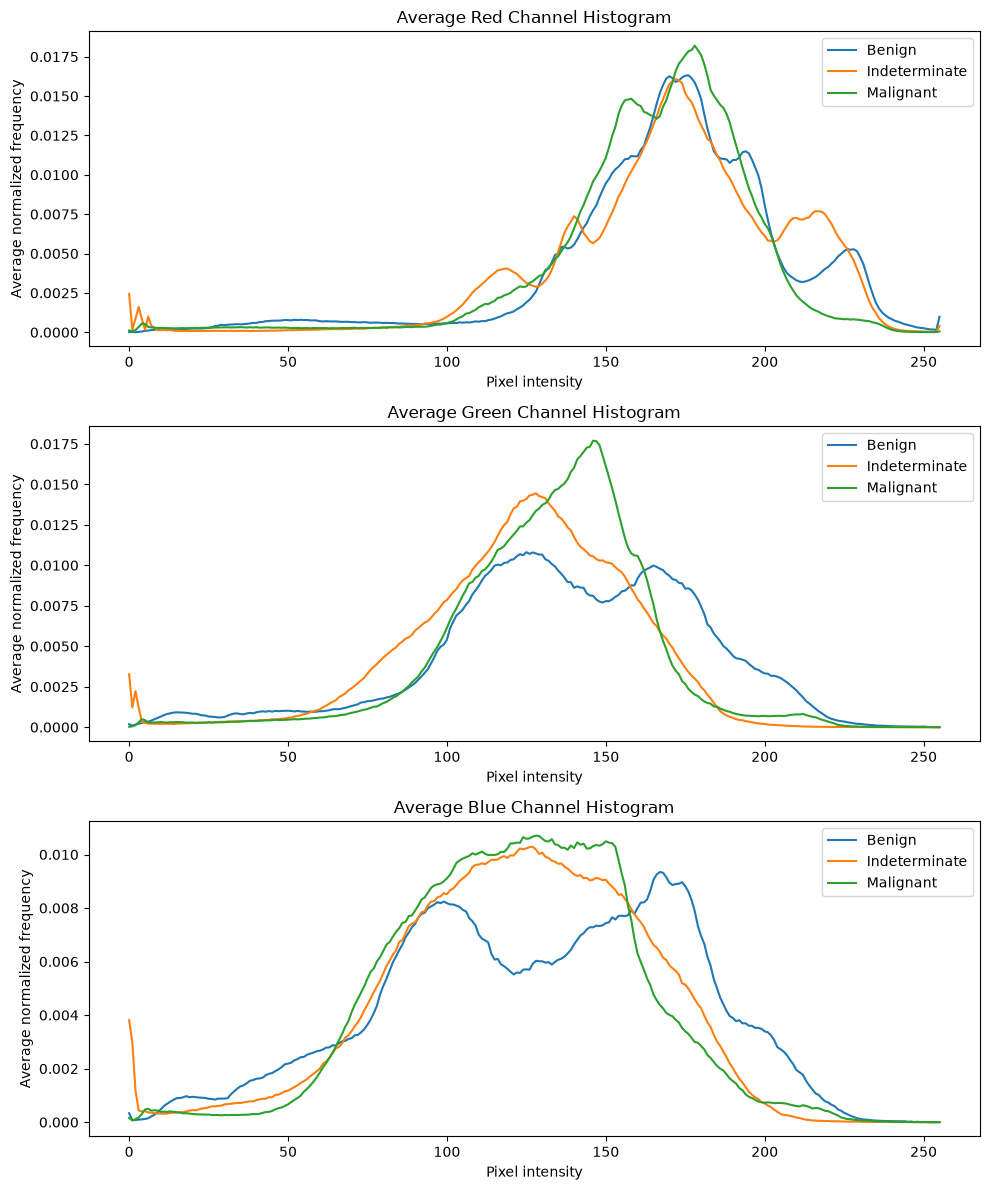

In [31]:
# Part 2.3 — Average RGB histogram per diagnosis class

def get_rgb_histograms(image_path):
    image = Image.open(image_path).convert("RGB")
    image_array = np.array(image)

    histograms = []

    for channel in range(3):
        hist, _ = np.histogram(
            image_array[:, :, channel],
            bins=256,
            range=(0, 256),
            density=True
        )
        histograms.append(hist)

    return histograms


rgb_histograms = {}

for diagnosis in ["Benign", "Indeterminate", "Malignant"]:
    class_histograms = []

    class_data = sampled_metadata[
        sampled_metadata["diagnosis_1"] == diagnosis
    ]

    for _, row in class_data.iterrows():
        image_path = os.path.join(image_dir, row["isic_id"] + ".jpg")

        if os.path.exists(image_path):
            class_histograms.append(get_rgb_histograms(image_path))

    rgb_histograms[diagnosis] = np.mean(class_histograms, axis=0)


# Plot RGB histograms
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, channel in enumerate(["Red", "Green", "Blue"]):
    for diagnosis in ["Benign", "Indeterminate", "Malignant"]:
        axes[i].plot(
            rgb_histograms[diagnosis][i],
            label=diagnosis
        )

    axes[i].set_title(f"Average {channel} Channel Histogram")
    axes[i].set_xlabel("Pixel intensity")
    axes[i].set_ylabel("Average normalized frequency")
    axes[i].legend()

plt.tight_layout()
plt.show()

In [32]:
# Part 2.4 — Per-image RGB mean and standard deviation

rgb_stats = []

for _, row in sampled_metadata.iterrows():
    image_path = os.path.join(image_dir, row["isic_id"] + ".jpg")

    if os.path.exists(image_path):
        image = Image.open(image_path).convert("RGB")
        image_array = np.array(image).astype(float)

        rgb_stats.append({
            "diagnosis": row["diagnosis_1"],
            "R_mean": image_array[:, :, 0].mean(),
            "G_mean": image_array[:, :, 1].mean(),
            "B_mean": image_array[:, :, 2].mean(),
            "R_std": image_array[:, :, 0].std(),
            "G_std": image_array[:, :, 1].std(),
            "B_std": image_array[:, :, 2].std()
        })

rgb_stats_df = pd.DataFrame(rgb_stats)

print("Per-image RGB statistics:")
display(rgb_stats_df.head())

Per-image RGB statistics:


,diagnosis,R_mean,G_mean,B_mean,R_std,G_std,B_std
0,Benign,226.555626,199.030407,185.468781,12.390509,17.696636,24.803796
1,Benign,151.252581,118.399585,107.637152,13.242589,17.716065,19.698612
2,Benign,153.440741,150.976263,150.819130,42.082539,42.856026,42.769305
3,Benign,219.730615,182.464470,180.504689,19.785145,26.393876,37.024697
4,Benign,160.122233,108.632174,94.350341,15.094822,16.527410,17.879416


In [33]:
# Aggregate RGB statistics by diagnosis class

rgb_summary = rgb_stats_df.groupby("diagnosis").mean(numeric_only=True)

print("Average RGB statistics by diagnosis:")
display(rgb_summary.round(2))

Average RGB statistics by diagnosis:


,R_mean,G_mean,B_mean,R_std,G_std,B_std
diagnosis,,,,,,
Benign,169.98,138.28,129.37,24.16,29.49,32.09
Indeterminate,170.67,124.21,122.14,23.24,25.87,27.92
Malignant,165.11,132.82,122.46,20.76,23.10,23.28


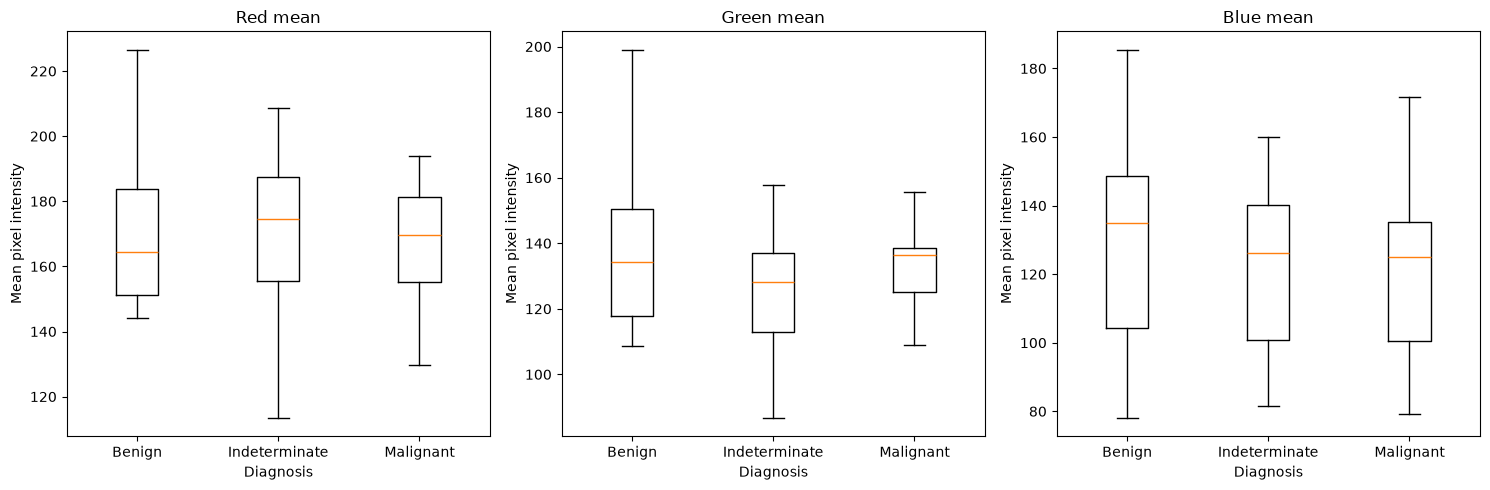

In [34]:
# Part 2.5 — RGB mean comparison by diagnosis

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

channels = ["R_mean", "G_mean", "B_mean"]
titles = ["Red mean", "Green mean", "Blue mean"]

for ax, channel, title in zip(axes, channels, titles):
    data_to_plot = [
        rgb_stats_df.loc[
            rgb_stats_df["diagnosis"] == diagnosis,
            channel
        ].dropna()
        for diagnosis in ["Benign", "Indeterminate", "Malignant"]
    ]

    ax.boxplot(
        data_to_plot,
        tick_labels=["Benign", "Indeterminate", "Malignant"]
    )

    ax.set_title(title)
    ax.set_xlabel("Diagnosis")
    ax.set_ylabel("Mean pixel intensity")

plt.tight_layout()
plt.show()

### Part 2.6 — Color and brightness interpretation

The RGB mean and standard deviation distributions show some differences in color and brightness between the diagnosis classes, but there is substantial overlap between the groups. Therefore, color and intensity may provide useful information to a model, but they are unlikely to be sufficient on their own to distinguish all diagnosis classes.

These differences may have several explanations. They could reflect characteristics of the lesions themselves, but they may also be influenced by factors such as lighting conditions, imaging equipment, image acquisition settings, or differences in the distribution of skin tones and anatomical sites across the dataset.

Because of this overlap and these possible alternative explanations, the image model should use more than simple color or brightness features. Shape, texture, lesion structure, and other visual characteristics may also be important.

In [37]:
# Part 3.1 — Reusable image processing function

def process_image(
    image_path,
    size=(224, 224),
    color_mode="RGB",
    normalization="minmax"
):
    """
    Load and process one image.

    Parameters:
        image_path: path to the image
        size: target image size (width, height)
        color_mode: "RGB" or "L" for grayscale
        normalization: "none", "minmax", or "zscore"

    Returns:
        processed_array: processed NumPy array
        info: dictionary containing shape and value range
    """

    # Load image
    image = Image.open(image_path)

    # Convert color
    if color_mode == "RGB":
        image = image.convert("RGB")
    elif color_mode == "L":
        image = image.convert("L")
    else:
        raise ValueError("color_mode must be 'RGB' or 'L'")

    # Resize
    image = image.resize(size)

    # Convert to NumPy array
    array = np.array(image).astype(np.float32)

    # Normalize
    if normalization == "none":
        processed_array = array

    elif normalization == "minmax":
        processed_array = array / 255.0

    elif normalization == "zscore":
        mean = array.mean()
        std = array.std()

        if std == 0:
            processed_array = array - mean
        else:
            processed_array = (array - mean) / std

    else:
        raise ValueError(
            "normalization must be 'none', 'minmax', or 'zscore'"
        )

    info = {
        "final_shape": processed_array.shape,
        "min_value": float(processed_array.min()),
        "max_value": float(processed_array.max()),
        "normalization": normalization,
        "color_mode": color_mode
    }

    return processed_array, info

In [38]:
# Test the processing function on one real image

test_image_path = os.path.join(
    image_dir,
    sampled_metadata.iloc[0]["isic_id"] + ".jpg"
)

processed_image, image_info = process_image(
    test_image_path,
    size=(224, 224),
    color_mode="RGB",
    normalization="minmax"
)

print("Processed image information:")
print(image_info)

Processed image information:
{'final_shape': (224, 224, 3), 'min_value': 0.2078431397676468, 'max_value': 1.0, 'normalization': 'minmax', 'color_mode': 'RGB'}


In [39]:
# Part 3.2 — Batch image processing

def process_image_batch(image_paths, size=(224, 224),
                        color_mode="RGB", normalization="minmax"):

    processed_images = []
    failures = []

    for image_path in image_paths:
        try:
            image_array, info = process_image(
                image_path,
                size=size,
                color_mode=color_mode,
                normalization=normalization
            )

            processed_images.append(image_array)

        except Exception as e:
            failures.append({
                "path": image_path,
                "reason": str(e)
            })

    return processed_images, failures

In [40]:
# Test batch processing on 10 real images

test_paths = [
    os.path.join(image_dir, image_id + ".jpg")
    for image_id in sampled_metadata["isic_id"].head(10)
]

processed_batch, failures = process_image_batch(
    test_paths,
    size=(224, 224),
    color_mode="RGB",
    normalization="minmax"
)

print("Number of images processed:", len(processed_batch))
print("Number of failures:", len(failures))

if failures:
    print("Failures:")
    for failure in failures:
        print(failure)

Number of images processed: 10
Number of failures: 0


In [41]:
# Part 3.3 — Test handling of a missing image

test_paths_with_bad_file = test_paths + [
    os.path.join(image_dir, "THIS_IMAGE_DOES_NOT_EXIST.jpg")
]

processed_batch, failures = process_image_batch(
    test_paths_with_bad_file,
    size=(224, 224),
    color_mode="RGB",
    normalization="minmax"
)

print("Number of images processed:", len(processed_batch))
print("Number of failures:", len(failures))

print("\nFailure report:")
for failure in failures:
    print("File:", failure["path"])
    print("Reason:", failure["reason"])

Number of images processed: 10
Number of failures: 1

Failure report:
File: ../data/milk10k/images/THIS_IMAGE_DOES_NOT_EXIST.jpg
Reason: [Errno 2] No such file or directory: '../data/milk10k/images/THIS_IMAGE_DOES_NOT_EXIST.jpg'


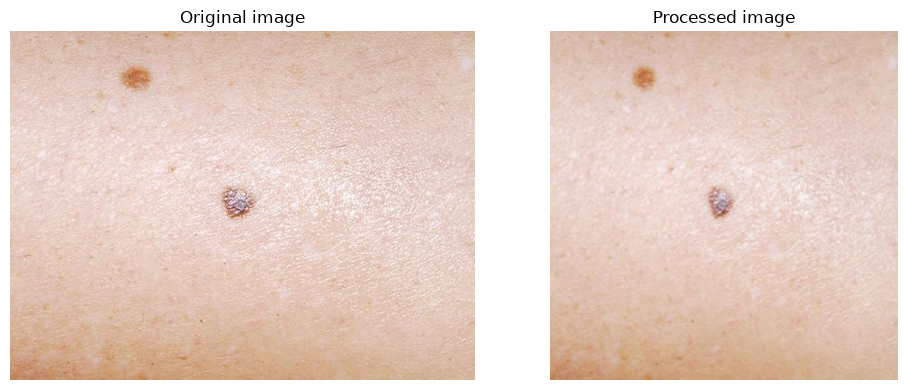

Original size: (600, 450)
Processed shape: (224, 224, 3)
Processed range: 0.20784314 to 1.0


In [43]:
# Part 3.4 — Visualize original vs processed image

test_path = test_paths[0]

original_image = Image.open(test_path).convert("RGB")

processed_image, info = process_image(
    test_path,
    size=(224, 224),
    color_mode="RGB",
    normalization="minmax"
)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_image)
plt.title("Processed image")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Original size:", original_image.size)
print("Processed shape:", processed_image.shape)
print("Processed range:",
      processed_image.min(),
      "to",
      processed_image.max())

In [44]:
# Part 4.1 — Data Loader

def image_data_loader(
    metadata_df,
    image_dir,
    batch_size=8,
    size=(224, 224),
    color_mode="RGB",
    normalization="minmax"
):
    """
    Generate batches of processed images and labels.

    Images are processed on the fly rather than
    loading the entire dataset into memory.
    """

    batch_images = []
    batch_labels = []

    for _, row in metadata_df.iterrows():

        image_path = os.path.join(
            image_dir,
            row["isic_id"] + ".jpg"
        )

        try:
            image_array, info = process_image(
                image_path,
                size=size,
                color_mode=color_mode,
                normalization=normalization
            )

            batch_images.append(image_array)
            batch_labels.append(row["diagnosis_1"])

            if len(batch_images) == batch_size:
                yield np.stack(batch_images), batch_labels

                batch_images = []
                batch_labels = []

        except Exception as e:
            print(
                f"Skipping {image_path}: {e}"
            )

    # Return remaining images if the final batch is incomplete
    if batch_images:
        yield np.stack(batch_images), batch_labels

In [45]:
# Test the data loader

loader = image_data_loader(
    sampled_metadata,
    image_dir,
    batch_size=8,
    size=(224, 224),
    color_mode="RGB",
    normalization="minmax"
)

first_batch_images, first_batch_labels = next(loader)

print("Batch image shape:", first_batch_images.shape)
print("Number of labels:", len(first_batch_labels))
print("Labels:", first_batch_labels)
print("Pixel range:",
      first_batch_images.min(),
      "to",
      first_batch_images.max())

Batch image shape: (8, 224, 224, 3)
Number of labels: 8
Labels: ['Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign', 'Benign']
Pixel range: 0.0 to 1.0


In [46]:
# Part 4.2 — Keep only images that exist locally

def filter_available_images(metadata_df, image_dir):
    available_rows = []
    missing_files = []

    for _, row in metadata_df.iterrows():

        image_path = os.path.join(
            image_dir,
            row["isic_id"] + ".jpg"
        )

        if os.path.exists(image_path):
            available_rows.append(row)
        else:
            missing_files.append(image_path)

    available_df = pd.DataFrame(available_rows).reset_index(drop=True)

    return available_df, missing_files

In [47]:
# Test the availability filter

available_metadata, missing_images = filter_available_images(
    sampled_metadata,
    image_dir
)

print("Images requested:", len(sampled_metadata))
print("Images available:", len(available_metadata))
print("Images missing:", len(missing_images))

if missing_images:
    print("\nMissing images:")
    for path in missing_images:
        print(path)

Images requested: 60
Images available: 60
Images missing: 0


In [48]:
# Part 4.3 — Test multiple batches

loader = image_data_loader(
    available_metadata,
    image_dir,
    batch_size=8,
    size=(224, 224),
    color_mode="RGB",
    normalization="minmax"
)

for batch_number, (batch_images, batch_labels) in enumerate(loader):
    print(
        f"Batch {batch_number + 1}: "
        f"images = {batch_images.shape}, "
        f"labels = {len(batch_labels)}"
    )

    # Show only the first 3 batches for testing
    if batch_number == 2:
        break

Batch 1: images = (8, 224, 224, 3), labels = 8
Batch 2: images = (8, 224, 224, 3), labels = 8
Batch 3: images = (8, 224, 224, 3), labels = 8


In [49]:
# Part 5.1 — Display a grid of images with labels

def show_image_grid(images, labels, n_images=8):
    """
    Display a grid of images with their diagnosis labels.
    """

    n_images = min(n_images, len(images))

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(12, 6)
    )

    axes = axes.flatten()

    for i in range(8):
        axes[i].axis("off")

        if i < n_images:
            image = images[i]

            # Make sure values are suitable for display
            image_display = np.clip(image, 0, 1)

            axes[i].imshow(image_display)
            axes[i].set_title(str(labels[i]))
            axes[i].axis("off")

    plt.tight_layout()
    plt.show()

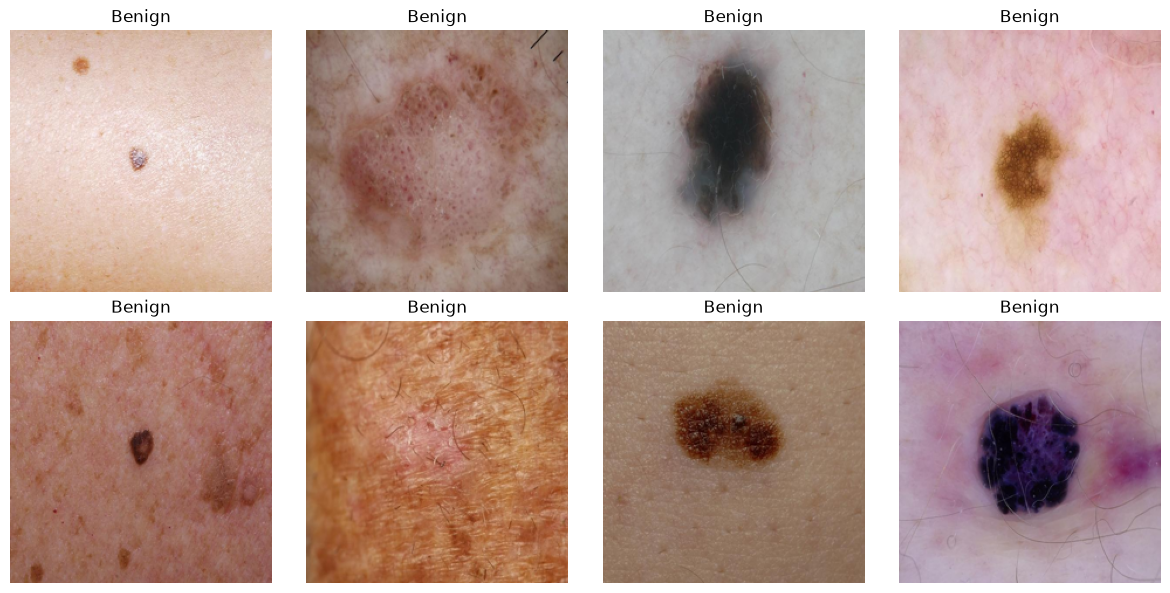

In [50]:
# Test the image grid

loader = image_data_loader(
    available_metadata,
    image_dir,
    batch_size=8,
    size=(224, 224),
    color_mode="RGB",
    normalization="minmax"
)

batch_images, batch_labels = next(loader)

show_image_grid(
    batch_images,
    batch_labels,
    n_images=8
)

Class distribution:
diagnosis_1
Malignant        7268
Benign           2966
Indeterminate     246
Name: count, dtype: int64


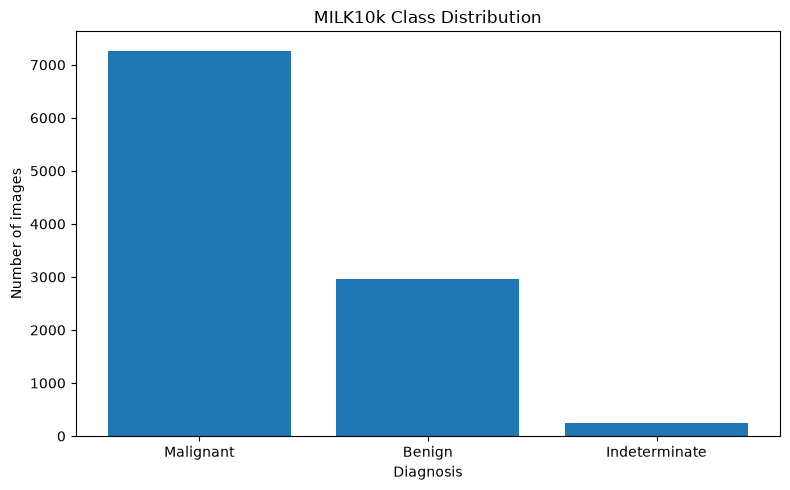

In [51]:
# Part 5.2 — Class balance

class_counts = metadata["diagnosis_1"].value_counts()

print("Class distribution:")
print(class_counts)

plt.figure(figsize=(8, 5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title("MILK10k Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of images")

plt.tight_layout()
plt.show()

Batch shape: (8, 224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Mean pixel value: 0.5770138
Standard deviation: 0.1885622


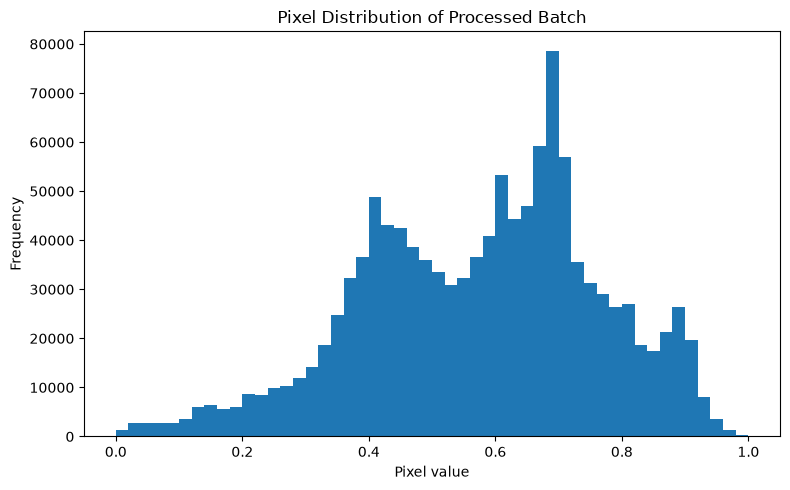

In [52]:
# Part 5.3 — Quick batch/debug summary

# Take one batch from the loader
loader = image_data_loader(
    available_metadata,
    image_dir,
    batch_size=8,
    size=(224, 224),
    color_mode="RGB",
    normalization="minmax"
)

batch_images, batch_labels = next(loader)

# Pixel statistics of the processed batch
print("Batch shape:", batch_images.shape)
print("Minimum pixel value:", batch_images.min())
print("Maximum pixel value:", batch_images.max())
print("Mean pixel value:", batch_images.mean())
print("Standard deviation:", batch_images.std())

# Plot processed pixel distribution
plt.figure(figsize=(8, 5))

plt.hist(
    batch_images.flatten(),
    bins=50
)

plt.title("Pixel Distribution of Processed Batch")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [53]:
import sys
sys.path.append("../src")

from milk10k_utils import process_image, process_image_batch, image_data_loader

In [55]:
test_path = test_paths[0]

processed_image, info = process_image(test_path)

print(info)

{'final_shape': (224, 224, 3), 'min_value': np.float32(0.20784314), 'max_value': np.float32(1.0), 'color_mode': 'RGB', 'normalization': 'minmax'}


In [56]:
processed_images, failures = process_image_batch(
    test_paths[:10]
)

print("Processed:", len(processed_images))
print("Failures:", len(failures))

Processed: 10
Failures: 0


In [57]:
loader = image_data_loader(
    available_metadata,
    image_dir,
    batch_size=8
)

batch_images, batch_labels = next(loader)

print("Batch shape:", batch_images.shape)
print("Number of labels:", len(batch_labels))
print("First labels:", batch_labels[:5])
print("Pixel range:", batch_images.min(), "to", batch_images.max())

Batch shape: (8, 224, 224, 3)
Number of labels: 8
First labels: ['Benign', 'Benign', 'Benign', 'Benign', 'Benign']
Pixel range: 0.0 to 1.0


## Reusable Computer Vision Functions

The reusable functions are stored in `src/milk10k_utils.py`:

- `process_image()` — resizes, converts color, and normalizes a single image.
- `process_image_batch()` — processes multiple images and reports failures.
- `image_data_loader()` — loads and processes images in batches without loading the full dataset into memory.
- `filter_available_images()` — identifies images that are available locally.
- `show_image_grid()` — visualizes image batches with their labels.

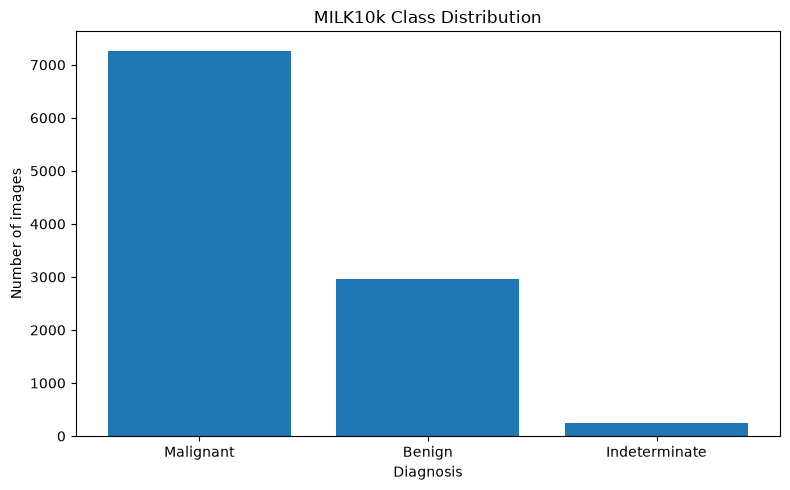

In [60]:
# Save class distribution figure for the report

class_counts = metadata["diagnosis_1"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title("MILK10k Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of images")

plt.tight_layout()

plt.savefig(
    "../data/report/figures/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 800x500 with 0 Axes>

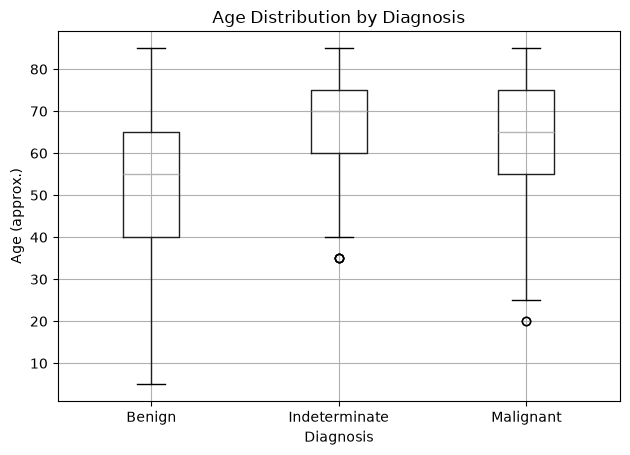

In [61]:
# Save age distribution figure for the report

plt.figure(figsize=(8, 5))

metadata.boxplot(
    column="age_approx",
    by="diagnosis_1"
)

plt.title("Age Distribution by Diagnosis")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.ylabel("Age (approx.)")

plt.tight_layout()

plt.savefig(
    "../data/report/figures/age_by_diagnosis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

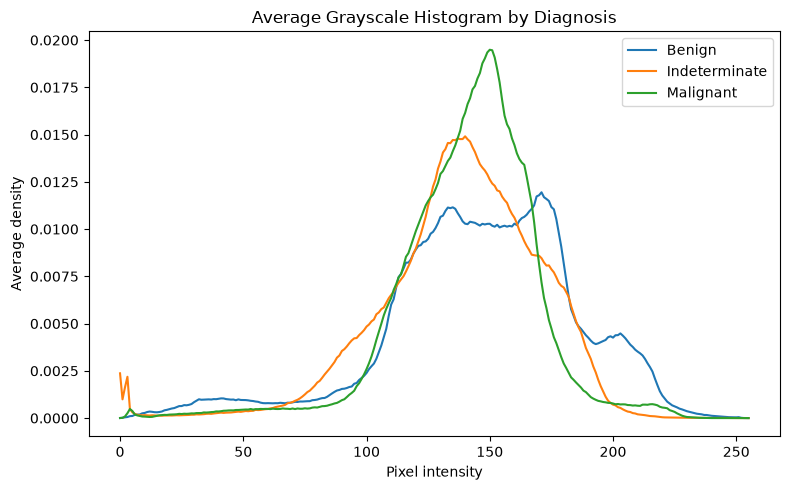

In [63]:
# Save grayscale histogram figure for the report

plt.figure(figsize=(8, 5))

for diagnosis in ["Benign", "Indeterminate", "Malignant"]:
    histograms = []

    class_images = sampled_metadata[
        sampled_metadata["diagnosis_1"] == diagnosis
    ]

    for _, row in class_images.iterrows():
        image_path = f"{image_dir}/{row['isic_id']}.jpg"

        image = Image.open(image_path).convert("L")
        image_array = np.array(image)

        hist, _ = np.histogram(
            image_array,
            bins=256,
            range=(0, 256),
            density=True
        )

        histograms.append(hist)

    average_histogram = np.mean(histograms, axis=0)

    plt.plot(
        average_histogram,
        label=diagnosis
    )

plt.title("Average Grayscale Histogram by Diagnosis")
plt.xlabel("Pixel intensity")
plt.ylabel("Average density")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../data/report/figures/grayscale_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

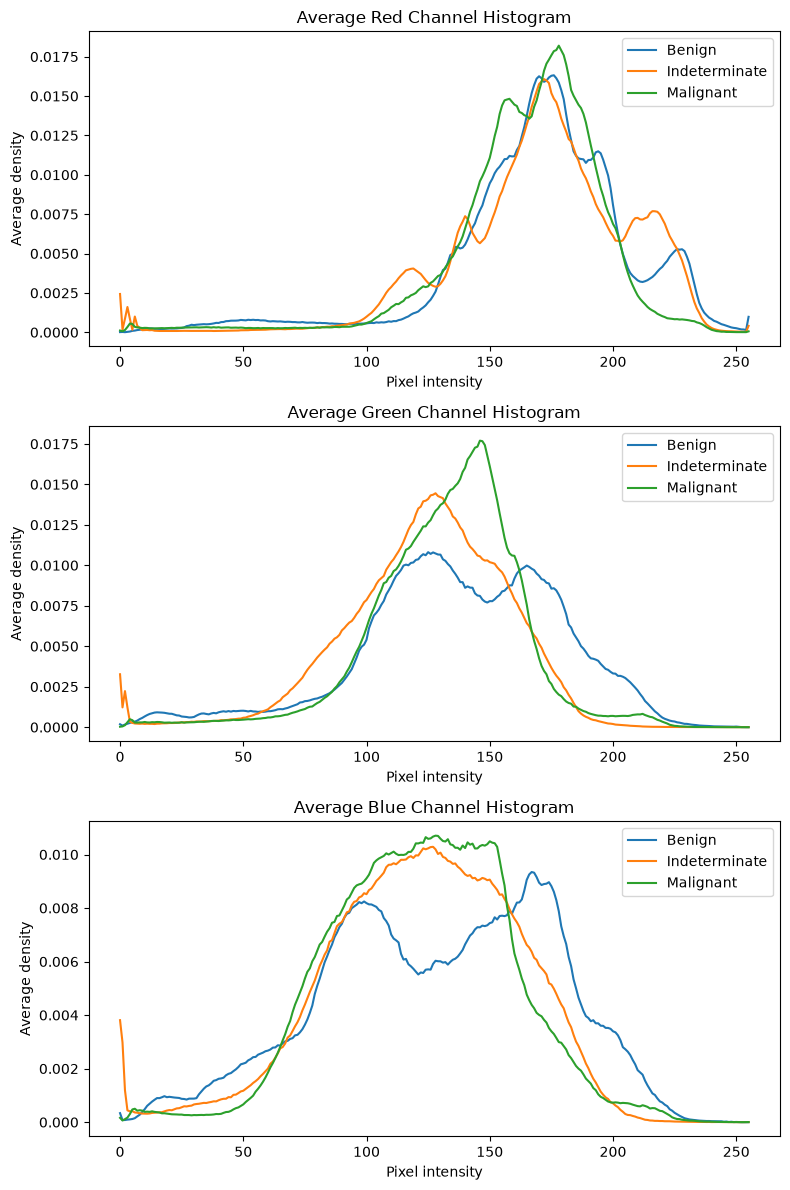

In [64]:
# Save RGB histogram figure for the report

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

channels = ["Red", "Green", "Blue"]

for channel_index, channel_name in enumerate(channels):

    for diagnosis in ["Benign", "Indeterminate", "Malignant"]:

        histograms = []

        class_images = sampled_metadata[
            sampled_metadata["diagnosis_1"] == diagnosis
        ]

        for _, row in class_images.iterrows():

            image_path = f"{image_dir}/{row['isic_id']}.jpg"

            image = Image.open(image_path).convert("RGB")
            image_array = np.array(image)

            hist, _ = np.histogram(
                image_array[:, :, channel_index],
                bins=256,
                range=(0, 256),
                density=True
            )

            histograms.append(hist)

        average_histogram = np.mean(histograms, axis=0)

        axes[channel_index].plot(
            average_histogram,
            label=diagnosis
        )

    axes[channel_index].set_title(
        f"Average {channel_name} Channel Histogram"
    )
    axes[channel_index].set_xlabel("Pixel intensity")
    axes[channel_index].set_ylabel("Average density")
    axes[channel_index].legend()

plt.tight_layout()

plt.savefig(
    "../data/report/figures/rgb_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

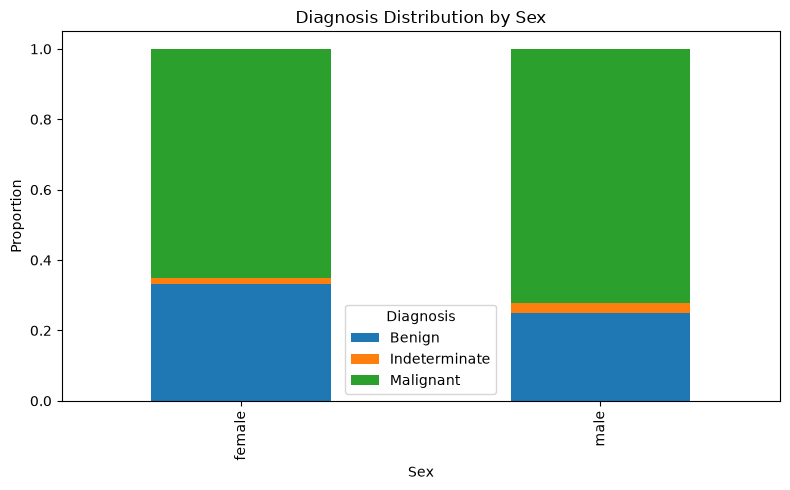

In [65]:
# Categorical metadata: sex vs diagnosis

metadata = pd.read_csv("../data/milk10k/metadata.csv")

sex_table = pd.crosstab(
    metadata["sex"],
    metadata["diagnosis_1"],
    normalize="index"
)

sex_table.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Diagnosis Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Proportion")
plt.legend(title="Diagnosis")

plt.tight_layout()

plt.savefig(
    "../data/report/figures/sex_by_diagnosis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

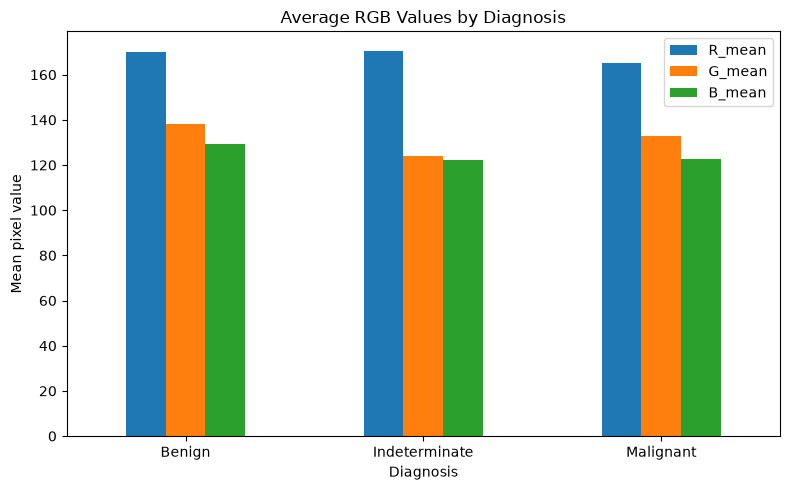

In [66]:
# Save RGB mean values by diagnosis

rgb_summary = rgb_stats_df.groupby("diagnosis")[
    ["R_mean", "G_mean", "B_mean"]
].mean()

rgb_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average RGB Values by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Mean pixel value")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../data/report/figures/rgb_mean_by_diagnosis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()